# E020 — Audio LPCC (LPC Cepstral Coefficients)

Replaces MFCC with LPCC — cepstral coefficients derived from LPC (all-pole
vocal tract model). Unlike MFCC, LPCC skips the mel warp and models the
spectral envelope as a minimum-phase all-pole filter, directly representing
vocal tract geometry.

**Feature dimension:** 13 static + Δ + ΔΔ = **39 features/frame** (same as E008)

Everything else identical to E008 +All:
- UBM 32, MAP r=16
- Augmentation: noise SNR=20dB + speed ±10%
- LOSO 3-fold, seed=67

E008 +All reference: fold0=3.47, fold1=8.33, fold2=0.83, mean=4.21±3.11%

In [1]:
from pathlib import Path
import sys, copy
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc
from scipy.special import logsumexp
from scipy.stats import norm as scipy_norm
import pandas as pd

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

COLORS = {
    "target":    "#E74C3C",
    "nontarget": "#2E86AB",
    "green":     "#27AE60",
    "purple":    "#8E44AD",
    "gray":      "#95A5A6",
    "orange":    "#E67E22",
}
CONFIG_COLORS = {
    "E008 +All (ref)": "#95A5A6",
    "LPCC +All":       "#E74C3C",
}
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA = Path("../data").resolve()
manifest = load_manifest(DATA)
y_all = manifest["label"].to_numpy()
SEED = 67
print(f"{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target")

222 samples — 30 target, 192 non-target


## 1. LPCC feature extraction

LPC models the vocal tract as an all-pole filter A(z). The LPC cepstrum is
derived from the LPC coefficients via the frequency-domain route:

1. Compute A(z) via LPC (Levinson-Durbin on each windowed frame)
2. Evaluate A at FFT frequencies: A(e^jω)
3. Log-spectrum of the all-pole model: log|H| = -log|A|
4. IFFT → take first `n_cep` coefficients

With LPC order=12, cepstrum order=13 we get the same 13+Δ+ΔΔ = 39d as E008.

In [2]:
def find_wav(stem: str, data_dir: Path) -> Path:
    for sf in ["target_train", "target_dev", "non_target_train", "non_target_dev"]:
        p = data_dir / sf / (stem + ".wav")
        if p.exists():
            return p
    raise FileNotFoundError(stem)


def extract_lpcc(y: np.ndarray, sr: int, order: int = 12, n_cep: int = 13,
                 hop_length: int = 160, win_length: int = 400) -> np.ndarray:
    """Extract LPCC+Δ+ΔΔ+CMN. Returns (T, 39)."""
    # Frame the signal
    frames = librosa.util.frame(y, frame_length=win_length, hop_length=hop_length)  # (win, T)
    lpcc_frames = []
    for frame in frames.T:
        frame = frame * np.hanning(len(frame))  # windowing
        try:
            a = librosa.lpc(frame.astype(np.float64), order=order)  # (order+1,)
            # Cepstrum via frequency domain: c = IFFT(log|1/A(e^jw)|) = IFFT(-log|A|)
            A_freq = np.fft.rfft(a, n=512)
            log_H = -np.log(np.abs(A_freq) + 1e-10)
            cep = np.real(np.fft.irfft(log_H))[:n_cep]
        except Exception:
            cep = np.zeros(n_cep)
        lpcc_frames.append(cep)

    lpcc = np.array(lpcc_frames, dtype=np.float32)   # (T, 13)
    delta  = librosa.feature.delta(lpcc.T).T
    delta2 = librosa.feature.delta(lpcc.T, order=2).T
    feat   = np.hstack([lpcc, delta, delta2])          # (T, 39)
    feat  -= feat.mean(axis=0)                         # CMN
    return feat


def aug_noise(y: np.ndarray, snr_db: float = 20.0, rng: np.random.Generator = None) -> np.ndarray:
    """Add white noise at target SNR."""
    signal_power = np.mean(y ** 2) + 1e-10
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise = rng.normal(0, np.sqrt(noise_power), len(y)).astype(y.dtype)
    return y + noise


def aug_speed(y: np.ndarray, rate_range=(0.9, 1.1), rng: np.random.Generator = None) -> np.ndarray:
    """Random time stretch without changing pitch."""
    rate = rng.uniform(*rate_range)
    return librosa.effects.time_stretch(y, rate=rate)


def load_and_augment(wav_path: Path, rng: np.random.Generator):
    """
    Load WAV and return list of (y, sr) tuples: [original, noisy, speed-perturbed].
    Matches E008 +All augmentation.
    """
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    return [
        (y, sr),
        (aug_noise(y, snr_db=20.0, rng=rng), sr),
        (aug_speed(y, rng=rng), sr),
    ]


def extract_batch(df: pd.DataFrame, data_dir: Path, seed: int):
    """Extract LPCC features for all samples with +All augmentation."""
    rng = np.random.default_rng(seed)
    all_feat, all_labels = [], []
    for _, row in df.iterrows():
        for y_aug, sr in load_and_augment(find_wav(row["stem"], data_dir), rng):
            feat = extract_lpcc(y_aug, sr)
            all_feat.append(feat)
            all_labels.extend([row["label"]] * len(feat))
    return np.vstack(all_feat), np.array(all_labels)


def score_utterance_lpcc(wav_path: Path, adapted: GaussianMixture, ubm: GaussianMixture) -> float:
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    feat  = extract_lpcc(y, sr)
    return float((adapted.score_samples(feat) - ubm.score_samples(feat)).mean())


# Sanity check dimensions
sample_row = manifest[manifest.label == 1].iloc[0]
y_tmp, sr_tmp = librosa.load(find_wav(sample_row["stem"], DATA), sr=None, mono=True)
feat_tmp = extract_lpcc(y_tmp, sr_tmp)
print(f"LPCC feature shape: {feat_tmp.shape}  (T frames × 39 dims)")
print(f"  static LPCC: 13 dims, delta: 13, delta2: 13, total: 39")
print(f"  Same dimensionality as E008 MFCC+Δ+ΔΔ")
print("Feature extraction functions defined.")

LPCC feature shape: (693, 39)  (T frames × 39 dims)
  static LPCC: 13 dims, delta: 13, delta2: 13, total: 39
  Same dimensionality as E008 MFCC+Δ+ΔΔ
Feature extraction functions defined.


## 2. LPCC vs MFCC visualization

Compare MFCC+Δ+ΔΔ (39d) with LPCC+Δ+ΔΔ (39d) for a target sample.
Both have the same dimensionality; the difference is in spectral representation:
MFCC uses mel warp + DCT; LPCC uses LPC all-pole model + cepstral recursion.

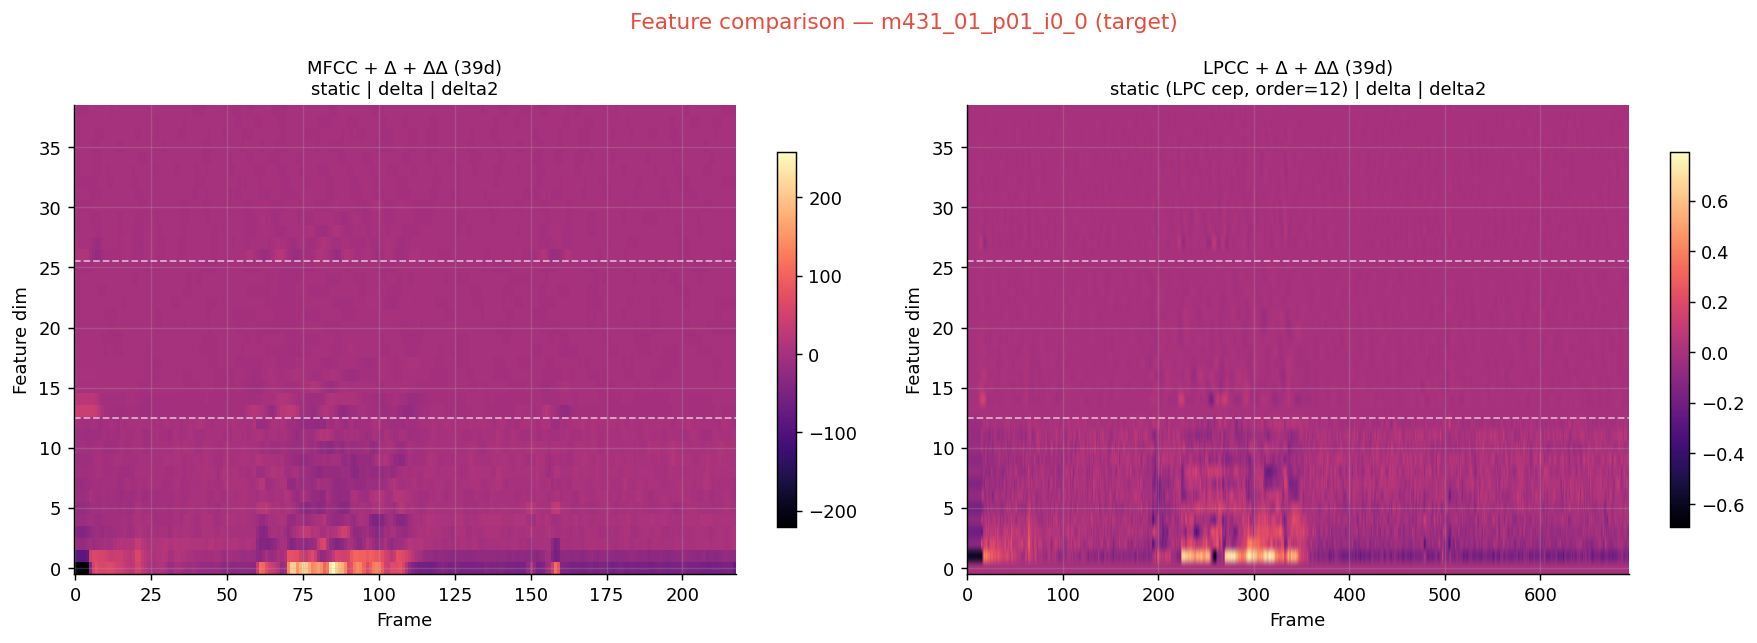

Both: 39 dims/frame — same shape, different spectral representation


In [3]:
y_viz, sr_viz = librosa.load(find_wav(sample_row["stem"], DATA), sr=None, mono=True)

# Standard MFCC+Δ+ΔΔ (39d)
mfcc_raw = librosa.feature.mfcc(y=y_viz, sr=sr_viz, n_mfcc=13)
delta  = librosa.feature.delta(mfcc_raw)
delta2 = librosa.feature.delta(mfcc_raw, order=2)
mfcc_39 = np.vstack([mfcc_raw, delta, delta2]).T
mfcc_39 -= mfcc_39.mean(axis=0)

# LPCC+Δ+ΔΔ (39d)
lpcc_39 = extract_lpcc(y_viz, sr_viz)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(mfcc_39.T, aspect="auto", origin="lower", cmap="magma")
ax.axhline(12.5, color="white", lw=1, ls="--", alpha=0.6)
ax.axhline(25.5, color="white", lw=1, ls="--", alpha=0.6)
ax.set_title(f"MFCC + Δ + ΔΔ (39d)\nstatic | delta | delta2", fontsize=10)
ax.set_xlabel("Frame")
ax.set_ylabel("Feature dim")
plt.colorbar(im, ax=ax, shrink=0.8)

ax = axes[1]
im = ax.imshow(lpcc_39.T, aspect="auto", origin="lower", cmap="magma")
ax.axhline(12.5, color="white", lw=1, ls="--", alpha=0.6)
ax.axhline(25.5, color="white", lw=1, ls="--", alpha=0.6)
ax.set_title(f"LPCC + Δ + ΔΔ (39d)\nstatic (LPC cep, order=12) | delta | delta2", fontsize=10)
ax.set_xlabel("Frame")
ax.set_ylabel("Feature dim")
plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f"Feature comparison — {sample_row['stem']} (target)",
             color=COLORS["target"], fontsize=12)
plt.tight_layout()
plt.show()
print(f"Both: 39 dims/frame — same shape, different spectral representation")

## 3. UBM + MAP functions

In [4]:
def train_ubm(X: np.ndarray, n_components: int = 32, seed: int = 67) -> GaussianMixture:
    return GaussianMixture(
        n_components=n_components, covariance_type="diag",
        max_iter=200, random_state=seed,
    ).fit(X)


def map_adapt(ubm: GaussianMixture, X_target: np.ndarray, r: float = 16.0) -> GaussianMixture:
    log_prob   = ubm._estimate_log_prob(X_target)
    log_resp   = log_prob + np.log(ubm.weights_)
    log_resp  -= logsumexp(log_resp, axis=1, keepdims=True)
    resp       = np.exp(log_resp)
    n_k        = resp.sum(axis=0)
    mu_hat     = (resp.T @ X_target) / (n_k[:, None] + 1e-10)
    alpha      = n_k / (n_k + r)
    adapted    = copy.deepcopy(ubm)
    adapted.means_ = alpha[:, None] * mu_hat + (1 - alpha[:, None]) * ubm.means_
    return adapted


print("UBM+MAP functions defined.")

UBM+MAP functions defined.


## 4. LOSO cross-validation — LPCC +All

Train UBM and MAP on augmented (+All) LPCC features from the train fold.
Val utterances always scored from original WAVs (no aug leakage).

In [5]:
UBM_COMPONENTS = 32
MAP_R = 16.0

# E008 +All reference
E008_REF = {"fold_eers": [3.47, 8.33, 0.83], "mean": 4.21, "std": 3.11, "min_dcf_mean": 0.0509}

print("Running LOSO CV — LPCC +All (39d features, UBM32, MAP r=16)")
print("=" * 60)

oof_scores   = np.full(len(manifest), np.nan)
fold_results = []

for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    train_df = manifest.loc[train_idx]
    val_df   = manifest.loc[val_idx]

    print(f"\nFold {fold_id}: {len(train_df)} train, {len(val_df)} val")

    # Augmented LPCC features — train fold only
    X_train, y_train = extract_batch(train_df, DATA, seed=SEED + fold_id)
    X_nt = X_train[y_train == 0]
    X_t  = X_train[y_train == 1]

    print(f"  {len(X_t)} target frames, {len(X_nt)} non-target frames (3× aug)")
    print(f"  Feature dim: {X_train.shape[1]}")

    ubm     = train_ubm(X_nt, n_components=UBM_COMPONENTS, seed=SEED)
    adapted = map_adapt(ubm, X_t, r=MAP_R)

    # Score val on ORIGINAL WAVs only
    for idx, row in val_df.iterrows():
        oof_scores[idx] = score_utterance_lpcc(find_wav(row["stem"], DATA), adapted, ubm)

    val_scores = oof_scores[val_idx]
    val_labels = manifest.loc[val_idx, "label"].to_numpy()
    eer, _     = compute_eer(val_scores[val_labels==1], val_scores[val_labels==0])
    min_dcf, _ = compute_min_dcf(val_scores[val_labels==1], val_scores[val_labels==0])
    fold_results.append({"fold": fold_id, "eer": eer, "min_dcf": min_dcf})

    ref = E008_REF["fold_eers"][fold_id]
    delta_str = f"{(eer*100 - ref):+.2f}pp vs E008"
    print(f"  → EER={eer*100:.2f}%  min-DCF={min_dcf:.4f}  ({delta_str})")

print("\n" + "=" * 60)
print("CV complete.")

Running LOSO CV — LPCC +All (39d features, UBM32, MAP r=16)

Fold 0: 140 train, 82 val
  48984 target frames, 545197 non-target frames (3× aug)
  Feature dim: 39
  → EER=9.17%  min-DCF=0.0833  (+5.70pp vs E008)

Fold 1: 152 train, 70 val
  52936 target frames, 574199 non-target frames (3× aug)
  Feature dim: 39
  → EER=0.83%  min-DCF=0.0167  (-7.50pp vs E008)

Fold 2: 152 train, 70 val
  54579 target frames, 601832 non-target frames (3× aug)
  Feature dim: 39
  → EER=0.00%  min-DCF=0.0000  (-0.83pp vs E008)

CV complete.


## 5. Results table

In [6]:
eers_lpcc  = [r["eer"]*100  for r in fold_results]
dcfs_lpcc  = [r["min_dcf"] for r in fold_results]
mean_lpcc  = np.mean(eers_lpcc)
std_lpcc   = np.std(eers_lpcc)
mean_dcf   = np.mean(dcfs_lpcc)

print(f"{'Config':<20} {'F0 EER':>8} {'F1 EER':>8} {'F2 EER':>8} {'Mean':>8} {'Std':>8} {'min-DCF':>9}")
print("-" * 72)
ref = E008_REF
print(f"{'E008 +All (ref)':<20} {ref['fold_eers'][0]:>8.2f} {ref['fold_eers'][1]:>8.2f} "
      f"{ref['fold_eers'][2]:>8.2f} {ref['mean']:>8.2f} {ref['std']:>8.2f} {ref['min_dcf_mean']:>9.4f}")
print(f"{'LPCC +All':<20} {eers_lpcc[0]:>8.2f} {eers_lpcc[1]:>8.2f} {eers_lpcc[2]:>8.2f} "
      f"{mean_lpcc:>8.2f} {std_lpcc:>8.2f} {mean_dcf:>9.4f}")
print("-" * 72)

delta = mean_lpcc - ref["mean"]
direction = "improvement" if delta < 0 else "regression"
print(f"\nLPCC +All vs E008 +All: {delta:+.2f}pp ({direction})")

eer_oof, _   = compute_eer(oof_scores[y_all==1], oof_scores[y_all==0])
dcf_oof, thr = compute_min_dcf(oof_scores[y_all==1], oof_scores[y_all==0])
print(f"OOF overall: EER={eer_oof*100:.2f}%, min-DCF={dcf_oof:.4f}, threshold={thr:.3f}")

Config                 F0 EER   F1 EER   F2 EER     Mean      Std   min-DCF
------------------------------------------------------------------------
E008 +All (ref)          3.47     8.33     0.83     4.21     3.11    0.0509
LPCC +All                9.17     0.83     0.00     3.33     4.14    0.0333
------------------------------------------------------------------------

LPCC +All vs E008 +All: -0.88pp (improvement)
OOF overall: EER=6.46%, min-DCF=0.1198, threshold=0.035


## 6. Per-fold bar chart + mean ± std

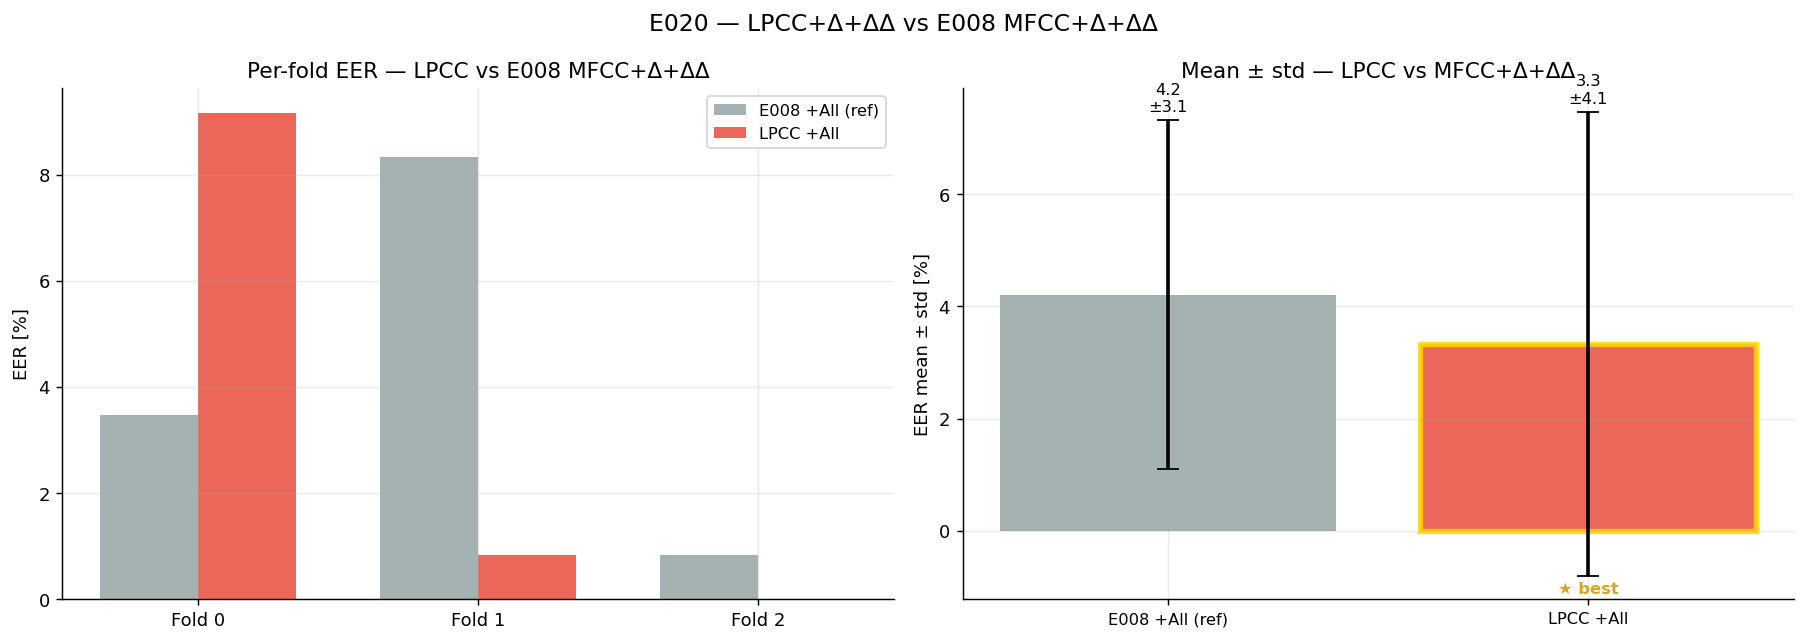

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs_bar = {
    "E008 +All (ref)": E008_REF["fold_eers"],
    "LPCC +All":       eers_lpcc,
}

# Per-fold grouped bars
ax = axes[0]
x = np.arange(3)
width = 0.35
for i, (cname, fold_eers) in enumerate(configs_bar.items()):
    offset = (i - 0.5) * width
    ax.bar(x + offset, fold_eers, width, label=cname,
           color=CONFIG_COLORS[cname], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(["Fold 0", "Fold 1", "Fold 2"])
ax.set_ylabel("EER [%]")
ax.set_title("Per-fold EER — LPCC vs E008 MFCC+Δ+ΔΔ")
ax.legend(fontsize=9)

# Mean ± std
ax = axes[1]
means_bar = [ref["mean"], mean_lpcc]
stds_bar  = [ref["std"],  std_lpcc]
cnames    = list(configs_bar.keys())
colors_b  = [CONFIG_COLORS[c] for c in cnames]
bars = ax.bar(range(2), means_bar, color=colors_b, alpha=0.85,
              yerr=stds_bar, capsize=6, error_kw=dict(elinewidth=2))
for bar, m, s in zip(bars, means_bar, stds_bar):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.15,
            f"{m:.1f}\n±{s:.1f}", ha="center", fontsize=9)
best_idx = int(np.argmin(means_bar))
bars[best_idx].set_edgecolor("gold")
bars[best_idx].set_linewidth(3)
ax.annotate("★ best", xy=(best_idx, means_bar[best_idx] - stds_bar[best_idx] - 0.3),
            ha="center", fontsize=9, color="goldenrod", fontweight="bold")
ax.set_xticks(range(2))
ax.set_xticklabels(cnames, fontsize=9)
ax.set_ylabel("EER mean ± std [%]")
ax.set_title("Mean ± std — LPCC vs MFCC+Δ+ΔΔ")

plt.suptitle("E020 — LPCC+Δ+ΔΔ vs E008 MFCC+Δ+ΔΔ", fontsize=13)
plt.tight_layout()
plt.show()

## 7. DET curve

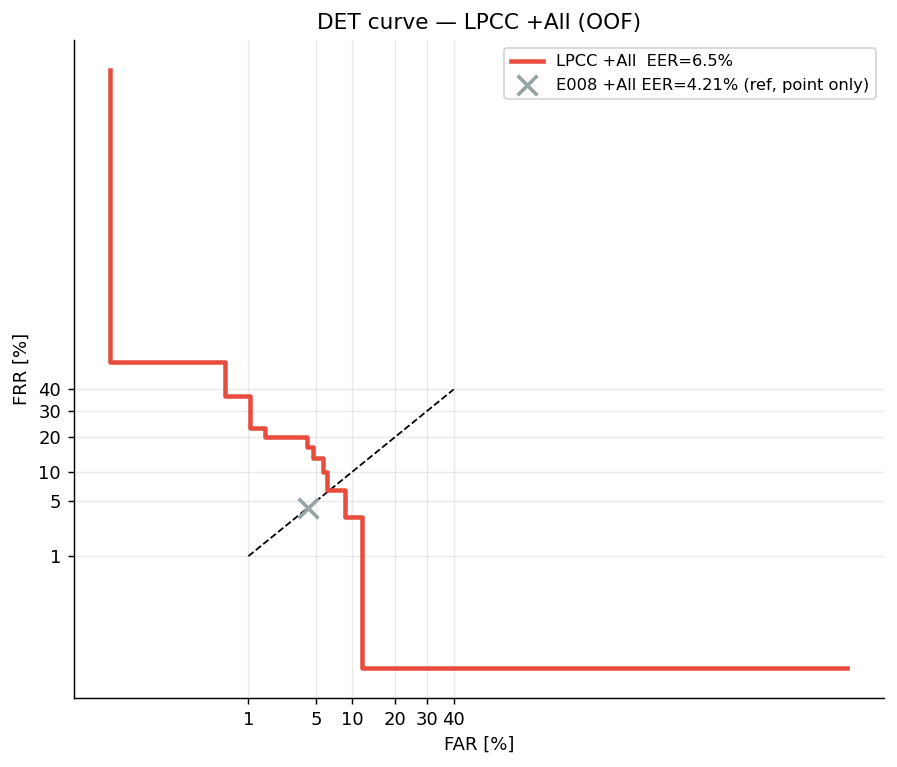

In [8]:
ticks = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
tick_pos    = [scipy_norm.ppf(t) for t in ticks]
tick_labels = [f"{int(t*100)}" for t in ticks]

fig, ax = plt.subplots(figsize=(7, 6))

# LPCC OOF DET
valid = ~np.isnan(oof_scores)
fpr, tpr, _ = roc_curve(y_all[valid], oof_scores[valid])
far_c = np.clip(fpr, 1e-4, 1-1e-4)
frr_c = np.clip(1-tpr, 1e-4, 1-1e-4)
ax.plot(scipy_norm.ppf(far_c), scipy_norm.ppf(frr_c),
        color=CONFIG_COLORS["LPCC +All"], lw=2.5,
        label=f"LPCC +All  EER={eer_oof*100:.1f}%", zorder=5)

# Reference E008 EER point on diagonal
e008_eer_norm = scipy_norm.ppf(E008_REF["mean"] / 100)
ax.scatter([e008_eer_norm], [e008_eer_norm], marker="x", s=120,
           color=CONFIG_COLORS["E008 +All (ref)"], zorder=6, lw=2,
           label=f"E008 +All EER={E008_REF['mean']:.2f}% (ref, point only)")

ax.plot(tick_pos, tick_pos, "k--", lw=1)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels)
ax.set_xlabel("FAR [%]")
ax.set_ylabel("FRR [%]")
ax.set_title("DET curve — LPCC +All (OOF)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Score distributions (2×2)

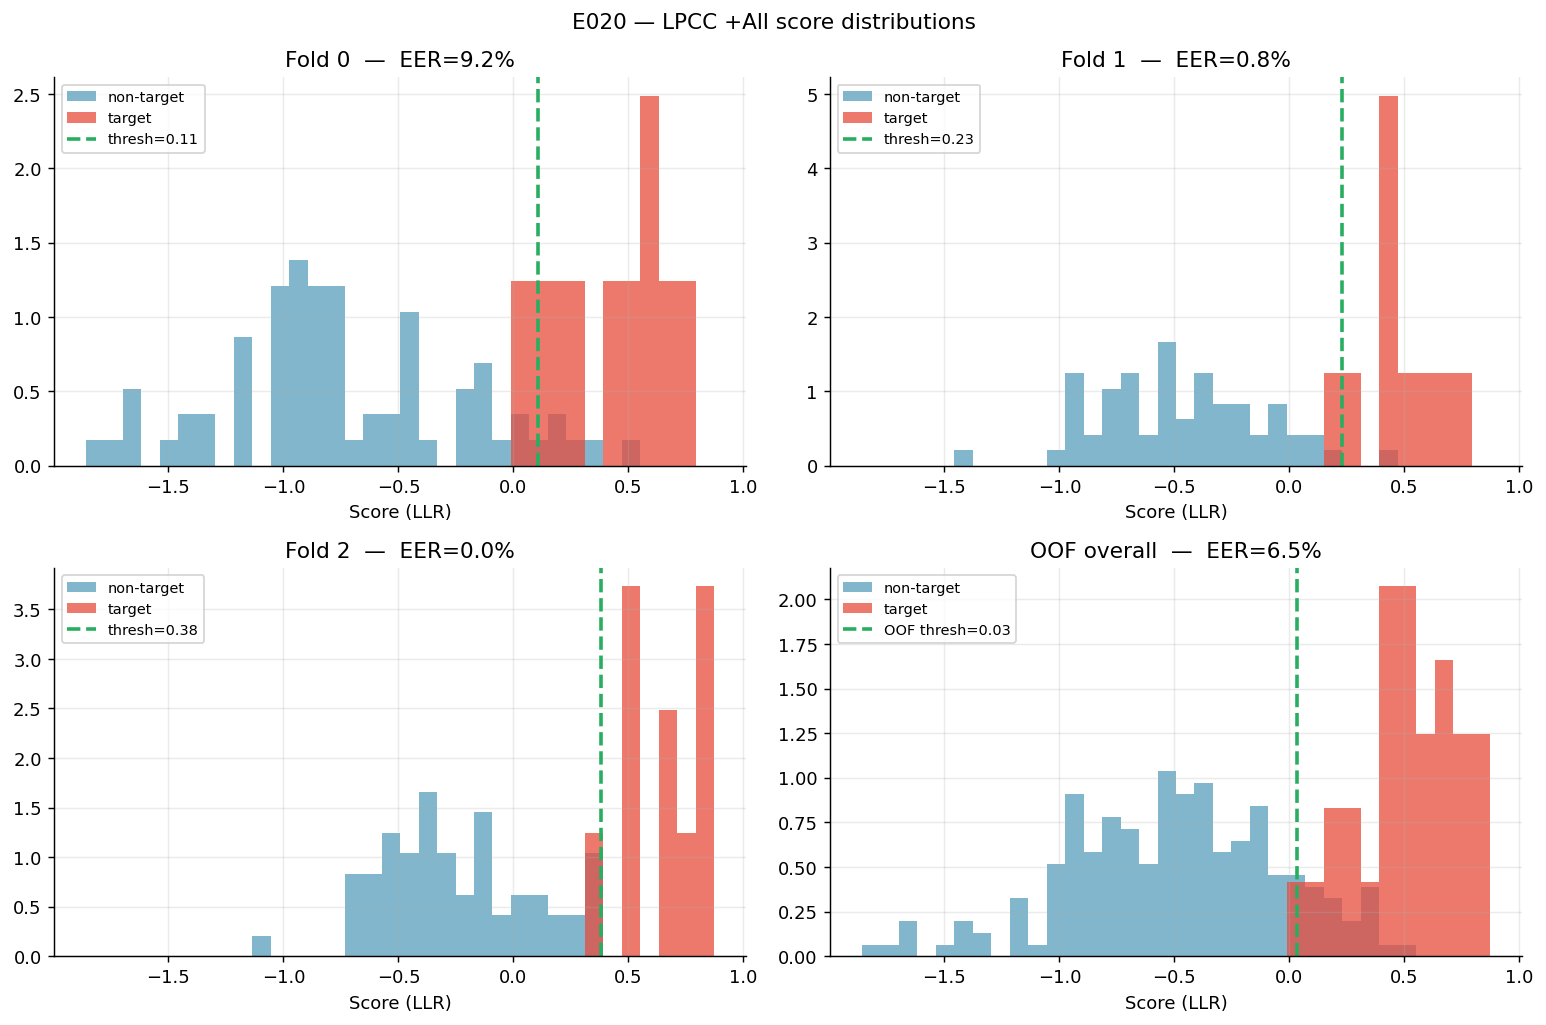


E020 LPCC — final numbers
LPCC +All:     EER=3.33±4.14%  min-DCF=0.0333
E008 +All ref: EER=4.21±3.11%  min-DCF=0.0509
Delta:         -0.88pp (improvement)
OOF overall:   EER=6.46%  min-DCF=0.1198  thr=0.035


In [9]:
fold_scores_list = []
for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    fold_scores_list.append({
        "scores": oof_scores[val_idx],
        "labels": manifest.loc[val_idx, "label"].to_numpy()
    })

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
finite_scores = oof_scores[~np.isnan(oof_scores)]
bin_edges = np.linspace(np.nanmin(finite_scores), np.nanmax(finite_scores), 35)

for i, (ax, fdata) in enumerate(zip(axes[:3], fold_scores_list)):
    s, l = fdata["scores"], fdata["labels"]
    eer_f, thr_f = compute_eer(s[l==1], s[l==0])
    ax.hist(s[l==0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"], label="non-target", density=True)
    ax.hist(s[l==1], bins=bin_edges, alpha=0.75, color=COLORS["target"], label="target", density=True)
    ax.axvline(thr_f, color=COLORS["green"], ls="--", lw=2, label=f"thresh={thr_f:.2f}")
    ax.set_title(f"Fold {i}  —  EER={eer_f*100:.1f}%")
    ax.set_xlabel("Score (LLR)")
    ax.legend(fontsize=8)

ax = axes[3]
ax.hist(oof_scores[y_all==0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"], label="non-target", density=True)
ax.hist(oof_scores[y_all==1], bins=bin_edges, alpha=0.75, color=COLORS["target"], label="target", density=True)
ax.axvline(thr, color=COLORS["green"], ls="--", lw=2, label=f"OOF thresh={thr:.2f}")
ax.set_title(f"OOF overall  —  EER={eer_oof*100:.1f}%")
ax.set_xlabel("Score (LLR)")
ax.legend(fontsize=8)

plt.suptitle("E020 — LPCC +All score distributions", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n{'='*55}")
print("E020 LPCC — final numbers")
print(f"{'='*55}")
print(f"LPCC +All:     EER={mean_lpcc:.2f}±{std_lpcc:.2f}%  min-DCF={mean_dcf:.4f}")
print(f"E008 +All ref: EER=4.21±3.11%  min-DCF=0.0509")
print(f"Delta:         {delta:+.2f}pp ({direction})")
print(f"OOF overall:   EER={eer_oof*100:.2f}%  min-DCF={dcf_oof:.4f}  thr={thr:.3f}")